In [1]:
import json
import re
import numpy as np
import pandas as pd
import re
from scipy.stats import pointbiserialr, spearmanr, ttest_ind, mannwhitneyu
import pingouin as pg
import rich

## Data Preparation

In [2]:
import json

with open('/data/user_data/wenkail/sotopia_diplomacy/processed_data_analysis/500_sample_with_taskeval_supply_center_qwen_judge.jsonl', 'r') as f:
    data = [json.loads(line) for line in f]

print(data[0])

In [16]:
# Iterate over all games and filter out messages where 'llm_judgement' does not contain exactly 8 yes/no answers
# For parsing, only use the part after </think>
filtered_data = []
not_8_matches_games = []

def extract_answers_after_think(llm_judgement):
    """
    Extracts the 8 yes/no answers after </think> from the llm_judgement string.
    Returns a list of matches (should be length 8 if valid), or [] if not found.
    """
    if not isinstance(llm_judgement, str):
        return []
    # Find the part after </think>
    split = llm_judgement.split("</think>")
    if len(split) < 2:
        return []
    after_think = split[1]
    # Only use the part after </think>
    # Find all lines like "1. Yes", "2. No", etc.
    matches = re.findall(r'\d+\.\s*(yes|no)', after_think.lower())
    return matches

for game in data:
    filtered_game = json.loads(json.dumps(game))  # Deep copy
    for phase in filtered_game.get('phases', []):
        filtered_messages = []
        for msg in phase.get('messages', []):
            if 'llm_judgement' in msg:
                s = msg['llm_judgement']
                matches = extract_answers_after_think(s)
                msg['llm_judgement_matches'] = matches
                if len(matches) == 8:
                    filtered_messages.append(msg)
                else:
                    msg['llm_judgement_matches'] = None
                    not_8_matches_games.append({'game_id': game.get('id'), 'phase': phase.get('name')})
            else:
                filtered_messages.append(msg)
        phase['messages'] = filtered_messages
    filtered_data.append(filtered_game)

# Calculate the proportion of not_8_matches_games
total_messages = 0
for game in data:
    for phase in game.get('phases', []):
        total_messages += len(phase.get('messages', []))

not_8_matches_count = len(not_8_matches_games)
if total_messages > 0:
    ratio = not_8_matches_count / total_messages
else:
    ratio = 0

print(f"Number of not_8_matches_games: {not_8_matches_count}")
print(f"Total number of messages: {total_messages}")
print(f"Proportion: {ratio:.2%}")

Number of not_8_matches_games: 13283
Total number of messages: 329454
Proportion: 4.03%


### Non-Binary

In [17]:
# This is for sender-based features

# 对每个year, 针对A phase，记录所有power的supply gain（center_increase）和taskeval，
# 只收集sender为该power的message（即只统计power主动发出的message），并计算8个LLM judgement特征的sum向量（统计有多少次yes）。
# 每个power都单独作为一行，后续做相关性分析。
# 现在把该power主动发出的所有message（文本）也放入dataframe，并且放在开头的columns

import numpy as np
from scipy.stats import pearsonr, spearmanr  # <-- Added import to fix NameError

# 特征名映射
feature_name_map = {
    'feature_0_yes_sum': "1. Game-Move",
    'feature_1_yes_sum': "2. Reasoning",
    'feature_2_yes_sum': "3. Rapport",
    'feature_3_yes_sum': "4. Apologies",
    'feature_4_yes_sum': "5. Compliment",
    'feature_5_yes_sum': "6. Personal-Thoughts",
    'feature_6_yes_sum': "7. Reassurance",
    'feature_7_yes_sum': "8. Share-Information"
}

results = []
for game in data:
    game_id = game.get('id')
    phases = game.get('phases', [])
    # Group phases by year
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        m = re.match(r'[SWF](\d{4})', phase_name)
        if not m:
            continue
        year = m.group(1)
        year_to_phases.setdefault(year, []).append(phase)
    # For each year, find the A phase and aggregate the 8 features for all phases in that year
    for year, year_phases in year_to_phases.items():
        # Find the A phase
        a_phase = None
        for phase in year_phases:
            if phase.get('name', '').endswith('A'):
                a_phase = phase
                break
        if a_phase is None:
            continue
        # 对A phase的所有power都记录
        center_info = a_phase.get('center_info', {})
        taskeval_info = a_phase.get('taskeval', {})
        for power, info in center_info.items():
            # 只收集sender为该power的message
            power_messages = []
            yes_sum = np.zeros(8, dtype=int)
            for phase in year_phases:
                for msg in phase.get('messages', []):
                    if msg is None:
                        continue
                    # 只考虑sender为该power的message
                    if msg.get('sender') == power:
                        power_messages.append(msg['message'])
                        s = msg.get('llm_judgement')
                        if not s:
                            continue
                        matches = extract_answers_after_think(s)
                        if len(matches) != 8:
                            continue
                        for i, val in enumerate(matches):
                            if val == 'yes':
                                yes_sum[i] += 1
            # 合并所有该power主动发出的message文本
            all_messages_str = "\n".join(power_messages)
            supply_gain = info.get('center_increase')
            taskeval_val = taskeval_info.get(power, np.nan)
            # message放在最前面
            results.append([all_messages_str, game_id, a_phase.get('name', ''), power] + list(yes_sum) + [supply_gain, taskeval_val])

# Build DataFrame
cols = ['messages', 'game_id', 'phase_name', 'power'] + [f'feature_{i}_yes_sum' for i in range(8)] + ['supply_gain', 'taskeval']
df_corr_sum = pd.DataFrame(results, columns=cols)

# 应用特征名映射
df_corr_sum = df_corr_sum.rename(columns=feature_name_map)

# ---------------------------------------------------
# 2) Correlation and nonparametric/effect size statistics summary
# ---------------------------------------------------
records = []

# 获取映射后的特征列名
feature_cols_mapped = [feature_name_map[f'feature_{i}_yes_sum'] for i in range(8)]

for feat in feature_cols_mapped:                     # Skip messages/game_id/phase_name/power, and exclude supply_gain, taskeval
    valid = df_corr_sum[[feat, 'supply_gain']].dropna()
    if valid[feat].nunique() < 2:           # All same value → skip
        continue

    # 相关性分析：sum特征与supply_gain的相关性
    r_pearson, p_pearson = pearsonr(valid[feat], valid['supply_gain'])
    r_spearman, p_spearman = spearmanr(valid[feat], valid['supply_gain'])

    records.append(dict(
        feature=feat,
        pearson_r=round(r_pearson, 3),
        p_pearson=round(p_pearson, 4),
        spearman_r=round(r_spearman, 3),
        p_spearman=round(p_spearman, 4),
    ))

final_df = pd.DataFrame(records).set_index('feature')
print("\n=== Combined correlation summary (sum up version) ===")
print(final_df)



=== Combined correlation summary (sum up version) ===
                      pearson_r  p_pearson  spearman_r  p_spearman
feature                                                           
1. Game-Move              0.236        0.0       0.362         0.0
2. Reasoning              0.180        0.0       0.296         0.0
3. Rapport                0.200        0.0       0.290         0.0
4. Apologies              0.179        0.0       0.234         0.0
5. Compliment             0.152        0.0       0.216         0.0
6. Personal-Thoughts      0.127        0.0       0.171         0.0
7. Reassurance            0.147        0.0       0.234         0.0
8. Share-Information      0.182        0.0       0.293         0.0


In [18]:
df_corr_sum['1. Game-Move'].value_counts()

1. Game-Move
0      9620
1      2978
2      2490
3      2163
4      1859
       ... 
98        1
83        1
104       1
76        1
77        1
Name: count, Length: 97, dtype: int64

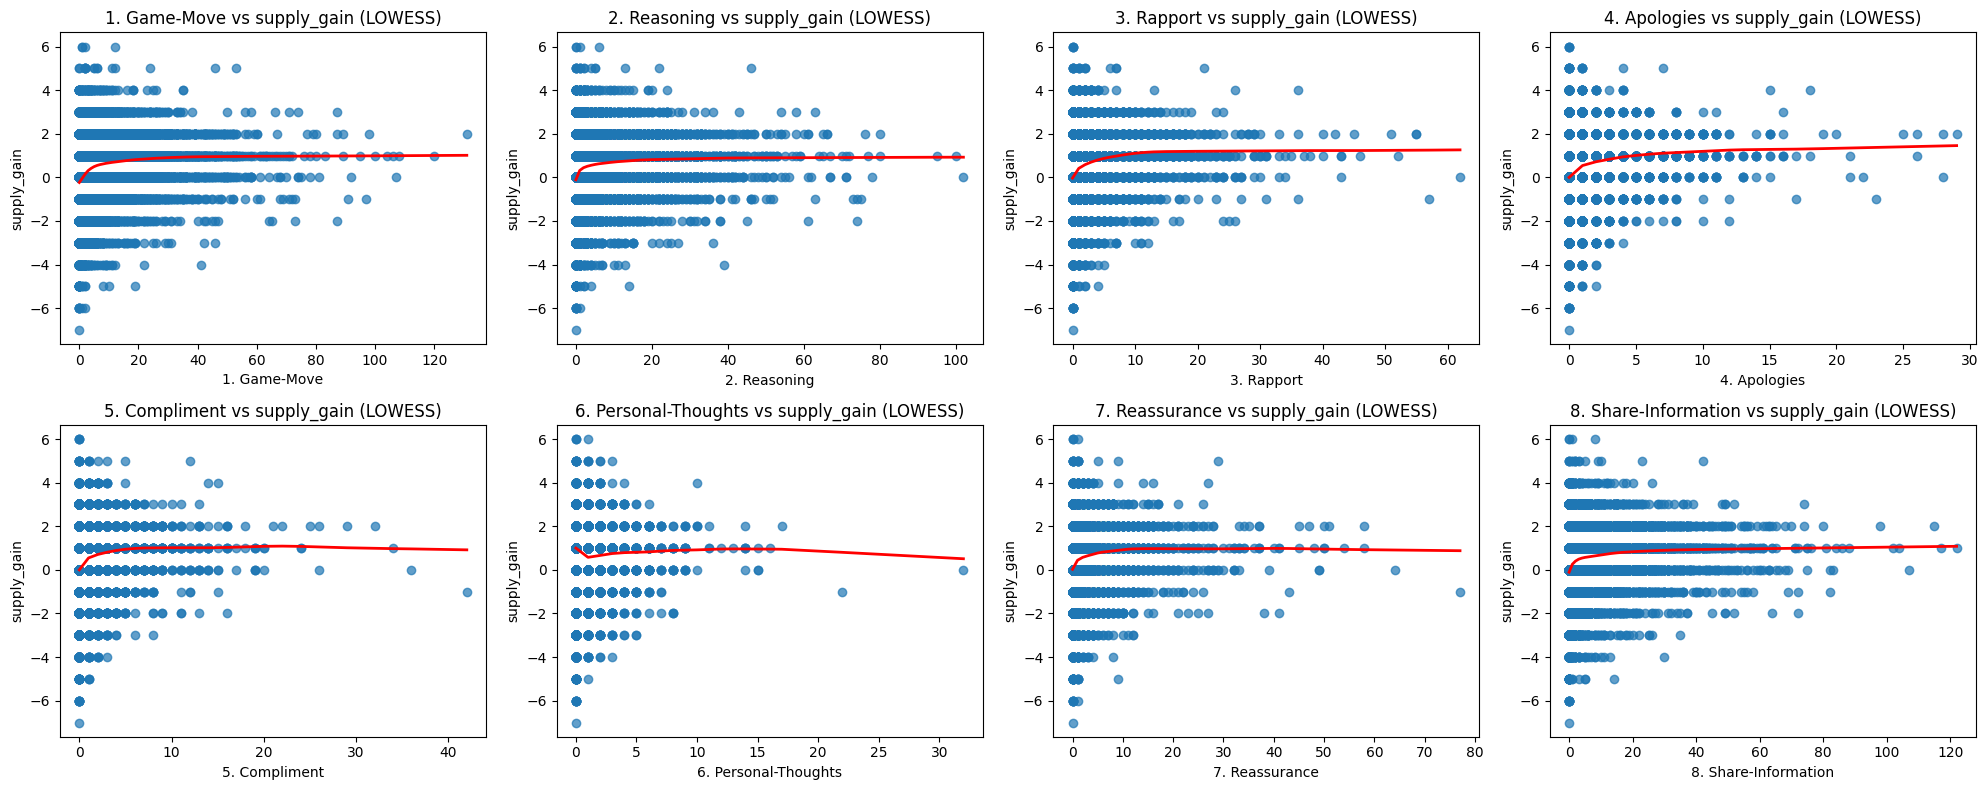

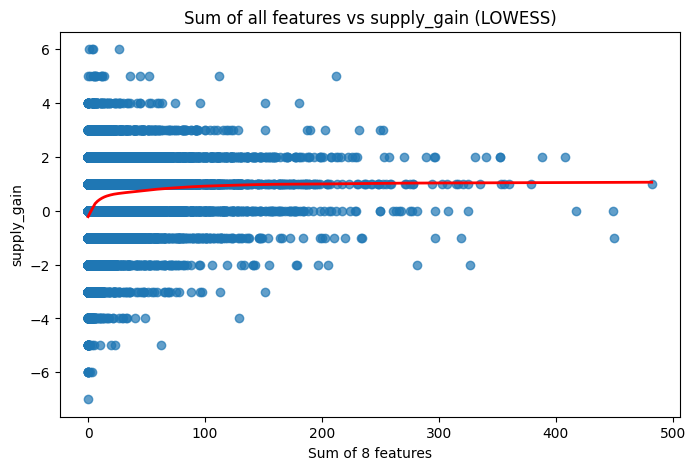

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Plot each feature vs supply_gain (非线性趋势：LOWESS曲线)
feature_cols = [
    "1. Game-Move", "2. Reasoning", "3. Rapport", "4. Apologies",
    "5. Compliment", "6. Personal-Thoughts", "7. Reassurance", "8. Share-Information"
]

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for idx, feat in enumerate(feature_cols):
    ax = axes[idx // 4, idx % 4]
    # 画出每个数据点的散点图和LOWESS平滑曲线
    sns.regplot(
        x=feat, 
        y="supply_gain", 
        data=df_corr_sum, 
        ax=ax,
        scatter_kws={'alpha': 0.7},
        line_kws={'color': 'red', 'linewidth': 2},
        lowess=True,   # 关键参数：非线性拟合
        ci=None
    )
    ax.set_title(f"{feat} vs supply_gain (LOWESS)")
    ax.set_xlabel(feat)
    ax.set_ylabel("supply_gain")
plt.tight_layout()
plt.show()

# 2. Plot sum of all features vs supply_gain (非线性趋势：LOWESS曲线)
df_corr_sum["features_sum"] = df_corr_sum[feature_cols].sum(axis=1)
plt.figure(figsize=(8, 5))
sns.regplot(
    x="features_sum", 
    y="supply_gain", 
    data=df_corr_sum, 
    scatter_kws={'alpha': 0.7},
    line_kws={'color': 'red', 'linewidth': 2},
    lowess=True,   # 关键参数：非线性拟合
    ci=None
)
plt.title("Sum of all features vs supply_gain (LOWESS)")
plt.xlabel("Sum of 8 features")
plt.ylabel("supply_gain")
plt.show()

### Binary Analysis

In [20]:
# This is for sender-based features

# 对每个year, 针对A phase，记录所有power的supply gain（center_increase）和taskeval，
# 只收集sender为该power的message（即只统计power主动发出的message），并计算8个LLM judgement特征的binary向量（只要有任何message该特征为yes则为1，否则为0）。
# 每个power都单独作为一行，后续做相关性分析。
# 现在把该power主动发出的所有message（文本）也放入dataframe，并且放在开头的columns

import numpy as np

# 特征名映射
feature_name_map = {
    'feature_0_yes_binary': "1. Game-Move",
    'feature_1_yes_binary': "2. Reasoning",
    'feature_2_yes_binary': "3. Rapport",
    'feature_3_yes_binary': "4. Apologies",
    'feature_4_yes_binary': "5. Compliment",
    'feature_5_yes_binary': "6. Personal-Thoughts",
    'feature_6_yes_binary': "7. Reassurance",
    'feature_7_yes_binary': "8. Share-Information"
}

results = []
for game in data:
    game_id = game.get('id')
    phases = game.get('phases', [])
    # Group phases by year
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        m = re.match(r'[SWF](\d{4})', phase_name)
        if not m:
            continue
        year = m.group(1)
        year_to_phases.setdefault(year, []).append(phase)
    # For each year, find the A phase and aggregate the 8 features for all phases in that year
    for year, year_phases in year_to_phases.items():
        # Find the A phase
        a_phase = None
        for phase in year_phases:
            if phase.get('name', '').endswith('A'):
                a_phase = phase
                break
        if a_phase is None:
            continue
        # 对A phase的所有power都记录
        center_info = a_phase.get('center_info', {})
        taskeval_info = a_phase.get('taskeval', {})
        for power, info in center_info.items():
            # 只收集sender为该power的message
            power_messages = []
            binary_yes = np.zeros(8, dtype=int)
            for phase in year_phases:
                for msg in phase.get('messages', []):
                    if msg is None:
                        continue
                    # 只考虑sender为该power的message
                    if msg.get('sender') == power:
                        power_messages.append(msg['message'])
                        s = msg.get('llm_judgement')
                        if not s:
                            continue
                        matches = extract_answers_after_think(s)
                        if len(matches) != 8:
                            continue
                        for i, val in enumerate(matches):
                            if val == 'yes':
                                binary_yes[i] = 1
            # 合并所有该power主动发出的message文本
            all_messages_str = "\n".join(power_messages)
            supply_gain = info.get('center_increase')
            taskeval_val = taskeval_info.get(power, np.nan)
            # message放在最前面
            results.append([all_messages_str, game_id, a_phase.get('name', ''), power] + list(binary_yes) + [supply_gain, taskeval_val])

# Build DataFrame
cols = ['messages', 'game_id', 'phase_name', 'power'] + [f'feature_{i}_yes_binary' for i in range(8)] + ['supply_gain', 'taskeval']
df_corr_binary = pd.DataFrame(results, columns=cols)

# 应用特征名映射
df_corr_binary = df_corr_binary.rename(columns=feature_name_map)

# ---------------------------------------------------
# 2) Correlation and nonparametric/effect size statistics summary
# ---------------------------------------------------
records = []

# 获取映射后的特征列名
feature_cols_mapped = [feature_name_map[f'feature_{i}_yes_binary'] for i in range(8)]

for feat in feature_cols_mapped:                     # Skip messages/game_id/phase_name/power, and exclude supply_gain, taskeval
    valid = df_corr_binary[[feat, 'supply_gain']].dropna()
    if valid[feat].nunique() < 2:           # All 0 or all 1 → skip
        continue

    x_yes = valid.loc[valid[feat] == 1, 'supply_gain']
    x_no  = valid.loc[valid[feat] == 0, 'supply_gain']

    # --- Linear / rank correlation ---
    r_pb, p_pb = pointbiserialr(valid[feat], valid['supply_gain'])
    r_sp, p_sp = spearmanr(valid[feat], valid['supply_gain'])

    # --- Welch t-test & Cohen’s d ---
    t_stat, p_t = ttest_ind(x_yes, x_no, equal_var=False)
    d = pg.compute_effsize(x_yes, x_no, eftype='cohen')

    # --- Mann-Whitney U & Rank-biserial r ---
    u_stat, p_u = mannwhitneyu(x_yes, x_no, alternative='two-sided')
    r_rb = 1 - 2 * u_stat / (len(x_yes) * len(x_no))

    # --- Cliff’s δ ---
    # delta = pg.compute_effsize(x_yes, x_no, eftype='cliff')

    records.append(dict(
        feature=feat,
        point_biserial_r=round(r_pb, 3),
        p_pb=round(p_pb, 4),
        spearman_r=round(r_sp, 3),
        p_sp=round(p_sp, 4),
        welch_t=round(t_stat, 3),
        p_t=round(p_t, 4),
        cohen_d=round(d, 3),
        mannwhitney_u=int(u_stat),
        p_u=round(p_u, 4),
        rank_biserial_r=round(r_rb, 3),
        # cliffs_delta=round(delta, 3),
    ))

final_df = pd.DataFrame(records).set_index('feature')
print("\n=== Combined correlation & effect-size summary ===")
print(final_df)



=== Combined correlation & effect-size summary ===
                      point_biserial_r  p_pb  spearman_r  p_sp  welch_t  p_t  \
feature                                                                        
1. Game-Move                     0.283   0.0       0.311   0.0   54.249  0.0   
2. Reasoning                     0.253   0.0       0.278   0.0   45.382  0.0   
3. Rapport                       0.244   0.0       0.268   0.0   43.220  0.0   
4. Apologies                     0.206   0.0       0.226   0.0   36.443  0.0   
5. Compliment                    0.194   0.0       0.210   0.0   34.196  0.0   
6. Personal-Thoughts             0.157   0.0       0.169   0.0   27.344  0.0   
7. Reassurance                   0.199   0.0       0.222   0.0   34.905  0.0   
8. Share-Information             0.243   0.0       0.268   0.0   43.454  0.0   

                      cohen_d  mannwhitney_u  p_u  rank_biserial_r  
feature                                                             
1. Game-M

In [21]:
# This is for recipient-side analysis

import numpy as np

# 特征名映射
feature_name_map = {
    'feature_0_yes_binary': "1. Game-Move",
    'feature_1_yes_binary': "2. Reasoning",
    'feature_2_yes_binary': "3. Rapport",
    'feature_3_yes_binary': "4. Apologies",
    'feature_4_yes_binary': "5. Compliment",
    'feature_5_yes_binary': "6. Personal-Thoughts",
    'feature_6_yes_binary': "7. Reassurance",
    'feature_7_yes_binary': "8. Share-Information"
}

results = []
for game in data:
    game_id = game.get('id')
    phases = game.get('phases', [])
    # Group phases by year
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        m = re.match(r'[SWF](\d{4})', phase_name)
        if not m:
            continue
        year = m.group(1)
        year_to_phases.setdefault(year, []).append(phase)
    # For each year, find the A phase and aggregate the 8 features for all phases in that year
    for year, year_phases in year_to_phases.items():
        # Find the A phase
        a_phase = None
        for phase in year_phases:
            if phase.get('name', '').endswith('A'):
                a_phase = phase
                break
        if a_phase is None:
            continue
        # 对A phase的所有power都记录
        center_info = a_phase.get('center_info', {})
        taskeval_info = a_phase.get('taskeval', {})
        for power, info in center_info.items():
            # 只收集recipient为该power的message
            power_messages = []
            binary_yes = np.zeros(8, dtype=int)
            for phase in year_phases:
                for msg in phase.get('messages', []):
                    if msg is None:
                        continue
                    # 只考虑recipient为该power的message
                    if msg.get('recipient') == power:
                        power_messages.append(msg['message'])
                        s = msg.get('llm_judgement')
                        if not s:
                            continue
                        matches = extract_answers_after_think(s)
                        if len(matches) != 8:
                            continue
                        for i, val in enumerate(matches):
                            if val == 'yes':
                                binary_yes[i] = 1
            # 合并所有该power主动发出的message文本
            all_messages_str = "\n".join(power_messages)
            supply_gain = info.get('center_increase')
            taskeval_val = taskeval_info.get(power, np.nan)
            # message放在最前面
            results.append([all_messages_str, game_id, a_phase.get('name', ''), power] + list(binary_yes) + [supply_gain, taskeval_val])

# Build DataFrame
cols = ['messages', 'game_id', 'phase_name', 'power'] + [f'feature_{i}_yes_binary' for i in range(8)] + ['supply_gain', 'taskeval']
df_corr_binary = pd.DataFrame(results, columns=cols)

# 应用特征名映射
df_corr_binary = df_corr_binary.rename(columns=feature_name_map)

# ---------------------------------------------------
# 2) Correlation and nonparametric/effect size statistics summary
# ---------------------------------------------------
records = []

# 获取映射后的特征列名
feature_cols_mapped = [feature_name_map[f'feature_{i}_yes_binary'] for i in range(8)]

for feat in feature_cols_mapped:                     # Skip messages/game_id/phase_name/power, and exclude supply_gain, taskeval
    valid = df_corr_binary[[feat, 'supply_gain']].dropna()
    if valid[feat].nunique() < 2:           # All 0 or all 1 → skip
        continue

    x_yes = valid.loc[valid[feat] == 1, 'supply_gain']
    x_no  = valid.loc[valid[feat] == 0, 'supply_gain']

    # --- Linear / rank correlation ---
    r_pb, p_pb = pointbiserialr(valid[feat], valid['supply_gain'])
    r_sp, p_sp = spearmanr(valid[feat], valid['supply_gain'])

    # --- Welch t-test & Cohen’s d ---
    t_stat, p_t = ttest_ind(x_yes, x_no, equal_var=False)
    d = pg.compute_effsize(x_yes, x_no, eftype='cohen')

    # --- Mann-Whitney U & Rank-biserial r ---
    u_stat, p_u = mannwhitneyu(x_yes, x_no, alternative='two-sided')
    r_rb = 1 - 2 * u_stat / (len(x_yes) * len(x_no))

    # --- Cliff’s δ ---
    # delta = pg.compute_effsize(x_yes, x_no, eftype='cliff')

    records.append(dict(
        feature=feat,
        point_biserial_r=round(r_pb, 3),
        p_pb=round(p_pb, 4),
        spearman_r=round(r_sp, 3),
        p_sp=round(p_sp, 4),
        welch_t=round(t_stat, 3),
        p_t=round(p_t, 4),
        cohen_d=round(d, 3),
        mannwhitney_u=int(u_stat),
        p_u=round(p_u, 4),
        rank_biserial_r=round(r_rb, 3),
        # cliffs_delta=round(delta, 3),
    ))

final_df = pd.DataFrame(records).set_index('feature')
print("\n=== Combined correlation & effect-size summary ===")
print(final_df)



=== Combined correlation & effect-size summary ===
                      point_biserial_r  p_pb  spearman_r  p_sp  welch_t  p_t  \
feature                                                                        
1. Game-Move                     0.273   0.0       0.305   0.0   52.424  0.0   
2. Reasoning                     0.238   0.0       0.266   0.0   42.715  0.0   
3. Rapport                       0.221   0.0       0.247   0.0   38.816  0.0   
4. Apologies                     0.197   0.0       0.216   0.0   34.653  0.0   
5. Compliment                    0.159   0.0       0.179   0.0   27.731  0.0   
6. Personal-Thoughts             0.078   0.0       0.091   0.0   13.169  0.0   
7. Reassurance                   0.193   0.0       0.216   0.0   33.714  0.0   
8. Share-Information             0.241   0.0       0.269   0.0   43.409  0.0   

                      cohen_d  mannwhitney_u  p_u  rank_biserial_r  
feature                                                             
1. Game-M

In [22]:
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.set_option('display.width', None)
# pd.set_option('display.max_colwidth', None)
# df_corr_binary.head()

=== 每个feature的0/1比例（排除message, game_id, phase_name, power）===
                      0_ratio  1_ratio
1. Game-Move            0.310    0.690
2. Reasoning            0.436    0.564
3. Rapport              0.571    0.429
4. Apologies            0.743    0.257
5. Compliment           0.754    0.246
6. Personal-Thoughts    0.807    0.193
7. Reassurance          0.629    0.371
8. Share-Information    0.431    0.569


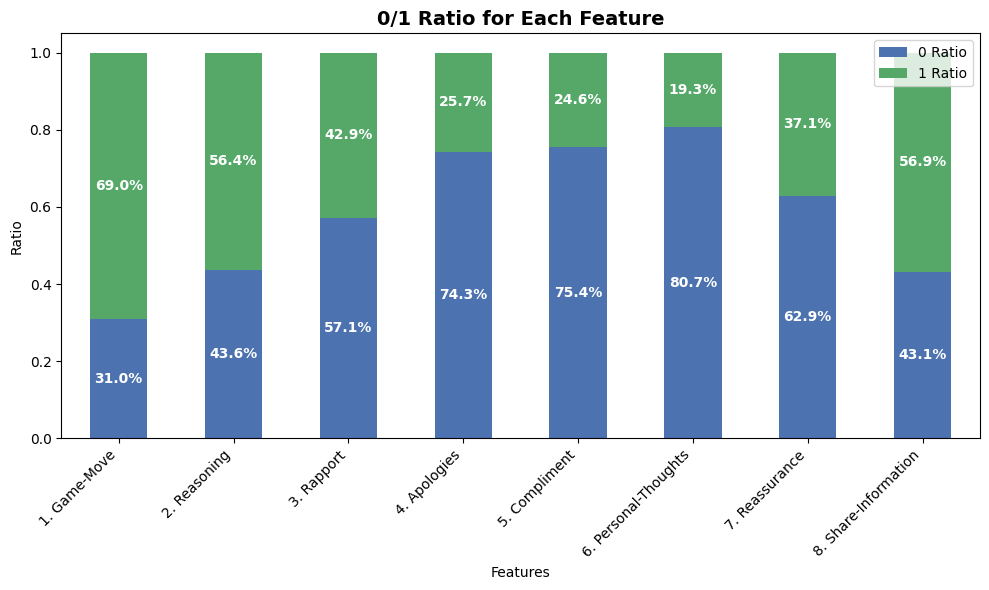

In [23]:
# 排除掉 message, game_id, phase_name, power 这四个columns，只针对剩下的二元特征列计算0/1比例并画bar plot，并在bar上写上百分比
import matplotlib.pyplot as plt
import pandas as pd

exclude_cols = {'messages', 'game_id', 'phase_name', 'power', 'supply_gain', 'taskeval'}
feature_cols = [col for col in df_corr_binary.columns if col not in exclude_cols]
feature_ratios = {}

for feat in feature_cols:
    counts = df_corr_binary[feat].value_counts(dropna=False)
    total = counts.sum()
    ratio_0 = counts.get(0, 0) / total
    ratio_1 = counts.get(1, 0) / total
    feature_ratios[feat] = {'0_ratio': round(ratio_0, 3), '1_ratio': round(ratio_1, 3)}

feature_ratio_df = pd.DataFrame(feature_ratios).T
print("=== 每个feature的0/1比例（排除message, game_id, phase_name, power）===")
print(feature_ratio_df)

# 画bar plot，并在bar上写上百分比
ax = feature_ratio_df[['0_ratio', '1_ratio']].plot(kind='bar', stacked=True, figsize=(10, 6), color=['#4C72B0', '#55A868'])
plt.title("0/1 Ratio for Each Feature", fontsize=14, fontweight='bold')
plt.ylabel("Ratio")
plt.xlabel("Features")
plt.xticks(rotation=45, ha='right')
plt.legend(["0 Ratio", "1 Ratio"])
plt.tight_layout()

# 在bar上写上百分比
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height*100:.1f}%', 
                        (bar.get_x() + bar.get_width() / 2, bar.get_y() + height / 2),
                        ha='center', va='center', fontsize=10, color='white', fontweight='bold')

plt.show()


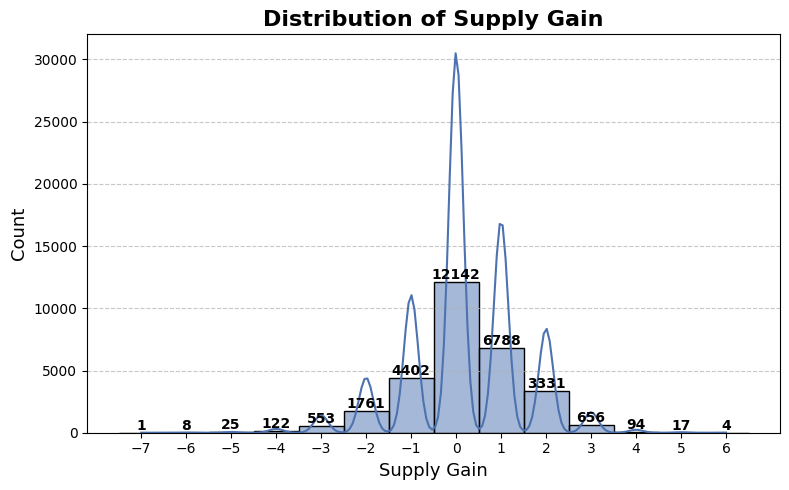

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 5))

# 只取非空整数的supply_gain
supply_gain = df_corr_binary["supply_gain"].dropna()
# 取所有出现过的整数
min_val = int(np.floor(supply_gain.min()))
max_val = int(np.ceil(supply_gain.max()))
bins = np.arange(min_val - 0.5, max_val + 1.5, 1)  # 以0.5为边界，确保每个整数为一个bin

ax = sns.histplot(supply_gain, bins=bins, kde=True, color="#4C72B0", edgecolor="black", discrete=True)
plt.title("Distribution of Supply Gain", fontsize=16, fontweight='bold')
plt.xlabel("Supply Gain", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 设置x轴为整数
ax.set_xticks(range(min_val, max_val + 1))

# 在bar顶端标上数字
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2, height), 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()


## Correlation Exploration

In [52]:
df_corr_binary.columns

Index(['messages', 'game_id', 'phase_name', 'power', '1. Game-Move',
       '2. Reasoning', '3. Rapport', '4. Apologies', '5. Compliment',
       '6. Personal-Thoughts', '7. Reassurance', '8. Share-Information',
       'supply_gain', 'taskeval'],
      dtype='object')

In [11]:
# # ----------------------------------------
# # 0) Dependencies
# # ----------------------------------------
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.model_selection       import train_test_split, ParameterGrid
# from sklearn.metrics               import (
#     accuracy_score, classification_report, confusion_matrix,
#     roc_auc_score, average_precision_score,
#     precision_recall_curve, roc_curve, f1_score
# )
# from sklearn.impute                import SimpleImputer

# import xgboost as xgb
# import warnings
# warnings.filterwarnings("ignore")


# # ----------------------------------------
# # 1) Data Preparation
# # ----------------------------------------
# # Assume df_corr_binary is already loaded in the environment

# # 1.1 Create binary label
# df_corr_binary['supply_gain_binary'] = (
#     df_corr_binary['supply_gain']
#     .apply(lambda x: 1 if x >= 1 else (0 if not np.isnan(x) else np.nan))
# )

# # 1.2 Select feature columns
# drop_cols = [
#     'supply_gain', 'supply_gain_binary', 'taskeval',
#     'game_id', 'phase_name', 'power', 'recipient',
#     'time_sent', 'messages', 'llm_judgement'
# ]
# feature_cols = [c for c in df_corr_binary.columns if c not in drop_cols]

# X = df_corr_binary[feature_cols]
# y = df_corr_binary['supply_gain_binary']

# # 1.3 Remove rows with missing labels
# mask = y.notna()
# X, y = X.loc[mask], y.loc[mask]

# # 1.4 Impute missing values (median)
# imputer = SimpleImputer(strategy="median")
# X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# # 1.5 Split train/test set (stratified)
# X_train, X_test, y_train, y_test = train_test_split(
#     X_imputed, y, test_size=0.2,
#     random_state=42, stratify=y
# )

# # 1.6 Compute scale_pos_weight
# pos = int(y_train.sum())
# neg = len(y_train) - pos
# scale_pos_weight = neg / pos
# print(f"[Info] Training set: pos={pos}, neg={neg}, scale_pos_weight={scale_pos_weight:.2f}")


# # ----------------------------------------
# # 2) Base Model Factory
# # ----------------------------------------
# def make_model(params):
#     """
#     params: dict of XGB hyperparameters (learning_rate, max_depth, etc.)
#     """
#     base = dict(
#         objective='binary:logistic',
#         eval_metric='logloss',
#         early_stopping_rounds=50,
#         n_estimators=2000,
#         # scale_pos_weight=scale_pos_weight,
#         random_state=42,
#         use_label_encoder=False
#     )
#     base.update(params)
#     return xgb.XGBClassifier(**base)


# # ----------------------------------------
# # 3) Evaluation Helper
# # ----------------------------------------
# def evaluate_model(model, X_test, y_test):
#     y_prob = model.predict_proba(X_test)[:, 1]
#     # default threshold = 0.5
#     y_pred = (y_prob >= 0.5).astype(int)
#     f1_default = f1_score(y_test, y_pred)
#     # find best threshold for max F1
#     prec, rec, thr = precision_recall_curve(y_test, y_prob)
#     f1s = 2 * prec * rec / (prec + rec + 1e-8)
#     best_i = np.nanargmax(f1s)
#     return {
#         'f1_default': f1_default,
#         'best_f1':      f1s[best_i],
#         'best_threshold': thr[best_i] if best_i < len(thr) else 0.5,
#         'roc_auc':      roc_auc_score(y_test, y_prob),
#         'pr_auc':       average_precision_score(y_test, y_prob)
#     }


# # ----------------------------------------
# # 4) Hyperparameter Grid Search
# # ----------------------------------------
# param_grid = {
#     'learning_rate':    [0.01, 0.03, 0.1],
#     'max_depth':        [4, 6, 8],
#     'subsample':        [0.7, 0.8, 1.0],
#     'colsample_bytree': [0.7, 0.8, 1.0],
#     'gamma':            [0, 1],
#     'reg_alpha':        [0, 1],
#     'reg_lambda':       [1, 5]
# }

# best_result = {'best_f1': 0}
# results = []

# total = len(list(ParameterGrid(param_grid)))
# for i, params in enumerate(ParameterGrid(param_grid), 1):
#     # 只tracking进度，不print每个效果
#     print(f"\rGrid search progress: {i}/{total}", end="")
#     model = make_model(params)
#     model.fit(
#         X_train, y_train,
#         eval_set=[(X_test, y_test)],
#         verbose=False
#     )
#     res = evaluate_model(model, X_test, y_test)
#     res.update(params)
#     res['best_iteration'] = model.best_iteration
#     results.append(res)
#     if res['best_f1'] > best_result.get('best_f1', 0):
#         best_result = res

# print("\n=== Best hyperparameters ===")
# print({k: best_result[k] for k in param_grid.keys()})
# print(f"Best F1 = {best_result['best_f1']:.3f} "
#       f"(@ threshold={best_result['best_threshold']:.3f}), "
#       f"default-F1={best_result['f1_default']:.3f}, "
#       f"ROC-AUC={best_result['roc_auc']:.3f}, PR-AUC={best_result['pr_auc']:.3f}, "
#       f"trees={best_result['best_iteration']}")

# # Optionally convert results to DataFrame for inspection:
# # df_results = pd.DataFrame(results).sort_values('best_f1', ascending=False)
# # display(df_results.head(10))


[Info] Training set: positive samples=8712, negative samples=15211, scale_pos_weight=1.75
[0]	validation_0-logloss:0.65423
[100]	validation_0-logloss:0.58168
[200]	validation_0-logloss:0.56753
[300]	validation_0-logloss:0.56466
[400]	validation_0-logloss:0.56398
[500]	validation_0-logloss:0.56382
[545]	validation_0-logloss:0.56379
[Info] Best iteration = 540

=== Classification Report ===
              precision    recall  f1-score   support

           0      0.728     0.804     0.764      3803
           1      0.581     0.475     0.522      2178

    accuracy                          0.684      5981
   macro avg      0.654     0.639     0.643      5981
weighted avg      0.674     0.684     0.676      5981

=== Confusion Matrix ===
[[3056  747]
 [1144 1034]]
ROC-AUC = 0.733
PR-AUC  = 0.549
Best F1 = 0.635 at threshold = 0.347
F1 at threshold=0.5: 0.522


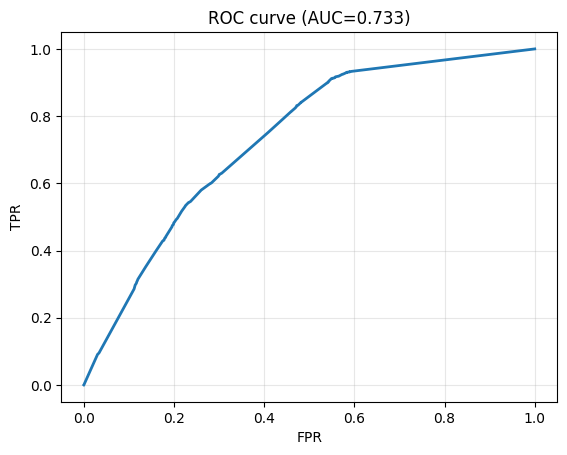

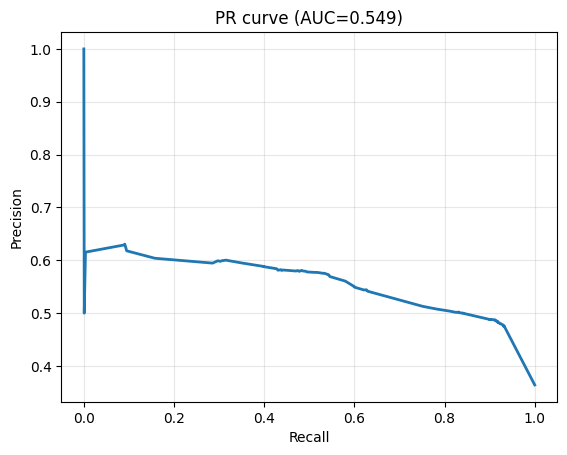


Top 20 features by gain:
1. Game-Move            332.112610
4. Apologies             16.522772
8. Share-Information      4.621319
3. Rapport                3.644818
6. Personal-Thoughts      2.072786
7. Reassurance            1.307934
5. Compliment             1.062546
2. Reasoning              0.969864
dtype: float64


In [25]:
# ----------------------------------------
# 0) Dependencies
# ----------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, average_precision_score,
    precision_recall_curve, roc_curve
)
from sklearn.impute import SimpleImputer

import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")


# ----------------------------------------
# 1) Data Preparation
# ----------------------------------------
# Assume df_corr_binary is already loaded in the environment

# 1.1 Create binary label
df_corr_binary['supply_gain_binary'] = (
    df_corr_binary['supply_gain']
    .apply(lambda x: 1 if x >= 1 else (0 if not np.isnan(x) else np.nan))
)

# 1.2 Select feature columns
drop_cols = [
    'supply_gain', 'supply_gain_binary', 'taskeval',
    'game_id', 'phase_name', 'power', 'recipient',
    'time_sent', 'messages', 'llm_judgement'
]
feature_cols = [c for c in df_corr_binary.columns if c not in drop_cols]

X = df_corr_binary[feature_cols]
y = df_corr_binary['supply_gain_binary']

# 1.3 Remove rows with missing labels
mask = y.notna()
X, y = X.loc[mask], y.loc[mask]

# 1.4 Impute missing values (using median)
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# 1.5 Split train/test set (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2,
    random_state=42, stratify=y
)

# 1.6 Calculate positive/negative sample ratio for scale_pos_weight
pos = int(y_train.sum())
neg = len(y_train) - pos
scale_pos_weight = neg / pos
print(f"[Info] Training set: positive samples={pos}, negative samples={neg}, scale_pos_weight={scale_pos_weight:.2f}")


# ----------------------------------------
# 2) Model Initialization (use best hyperparameters from grid search)
# ----------------------------------------
# Best hyperparameters from grid search:
# {'learning_rate': 0.01, 'max_depth': 4, 'subsample': 1.0, 'colsample_bytree': 1.0, 'gamma': 0, 'reg_alpha': 0, 'reg_lambda': 5}
model = xgb.XGBClassifier(
    objective            ='binary:logistic',
    eval_metric          ='logloss',
    early_stopping_rounds=5,
    n_estimators         =20000,
    learning_rate        =0.01,
    max_depth            =4,
    subsample            =1.0,
    colsample_bytree     =1.0,
    gamma                =0,
    reg_alpha            =0,
    reg_lambda           =5,
    # scale_pos_weight     =scale_pos_weight,
    random_state         =42,
    use_label_encoder    =False
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print(f"[Info] Best iteration = {model.best_iteration}")


# ----------------------------------------
# 3) Prediction & Evaluation
# ----------------------------------------
# Probability prediction & default 0.5 threshold
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.5).astype(int)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=3))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

# ROC-AUC & PR-AUC
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc  = average_precision_score(y_test, y_prob)
print(f"ROC-AUC = {roc_auc:.3f}")
print(f"PR-AUC  = {pr_auc:.3f}")


# ----------------------------------------
# 4) Best Threshold (Max F1)
# ----------------------------------------
prec, rec, thr = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * prec * rec / (prec + rec + 1e-8)
best_idx = np.nanargmax(f1_scores)
best_thr = thr[best_idx]
print(f"Best F1 = {f1_scores[best_idx]:.3f} at threshold = {best_thr:.3f}")

# Also show F1 at default threshold=0.5 for reference
from sklearn.metrics import f1_score
f1_default = f1_score(y_test, y_pred)
print(f"F1 at threshold=0.5: {f1_default:.3f}")

# ----------------------------------------
# 5) Visualization (Optional)
# ----------------------------------------
def plot_curve(x, y, xlabel, ylabel, title):
    plt.figure()
    plt.plot(x, y, lw=2)
    plt.xlabel(xlabel); plt.ylabel(ylabel); plt.title(title)
    plt.grid(alpha=0.3)
    plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
plot_curve(fpr, tpr, "FPR", "TPR", f"ROC curve (AUC={roc_auc:.3f})")
plot_curve(rec, prec, "Recall", "Precision", f"PR curve (AUC={pr_auc:.3f})")


# ----------------------------------------
# 6) Feature Importance
# ----------------------------------------
imp = pd.Series(
    model.get_booster().get_score(importance_type='gain')
).sort_values(ascending=False)
print("\nTop 20 features by gain:")
print(imp.head(20))

## Training Data Subsample

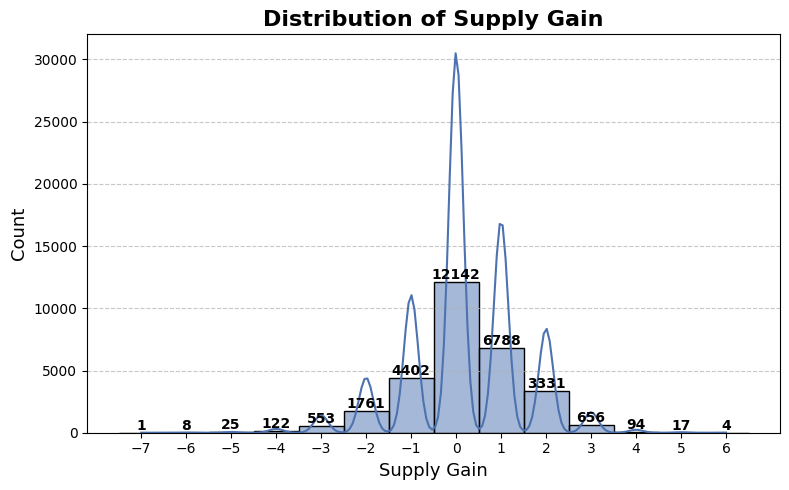

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(8, 5))

# 只取非空整数的supply_gain
supply_gain = df_corr_binary["supply_gain"].dropna()
# 取所有出现过的整数
min_val = int(np.floor(supply_gain.min()))
max_val = int(np.ceil(supply_gain.max()))
bins = np.arange(min_val - 0.5, max_val + 1.5, 1)  # 以0.5为边界，确保每个整数为一个bin

ax = sns.histplot(supply_gain, bins=bins, kde=True, color="#4C72B0", edgecolor="black", discrete=True)
plt.title("Distribution of Supply Gain", fontsize=16, fontweight='bold')
plt.xlabel("Supply Gain", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# 设置x轴为整数
ax.set_xticks(range(min_val, max_val + 1))

# 在bar顶端标上数字
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2, height), 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.show()


In [27]:
data[0]['phases'][0]['messages']

[{'sender': 'RUSSIA',
  'recipient': 'ITALY',
  'time_sent': 0,
  'phase': 'S1901M',
  'message': 'Would you like to coordinate an early assault on Austria? We can make a successful team\r',
  'llm_judgement': '<think>\nOkay, let\'s break down this statement step by step. The user provided a statement: "Would you like to coordinate an early assault on Austria? We can make a successful team." They want me to answer 8 yes/no questions about it based on the given categories.\n\nFirst, I need to check each question one by one.\n\n1. **Is this statement about the sender\'s or receiver\'s GAME MOVE?** The statement is asking if the receiver wants to coordinate an assault on Austria. This seems like a suggestion or proposal of a game move. The sender is suggesting a joint action, so this would be a game move. So answer YES.\n\n2. **Does this statement PROVIDE REASONS for the sender\'s or receiver\'s move?** The statement doesn\'t give any reasons why they should assault Austria. It\'s just a 

In [28]:
# 构建 sender-receiver 粒度的 dataframe，每一行是 sender 和 receiver 之间的一次“来回”对话（即 sender->receiver 的一条消息，紧跟着 receiver->sender 的一条回复，只有两条都在才存）。
# 每行包含：game_id, phase_name, sender, receiver, sender_message, receiver_message, sender_time_sent, receiver_time_sent, sender_message_features, receiver_message_features, receiver_supply_gain, sender_supply_gain, taskeval

import numpy as np
from tqdm import tqdm

# 特征名映射
feature_name_map = {
    'feature_0_yes': "1. Game-Move",
    'feature_1_yes': "2. Reasoning",
    'feature_2_yes': "3. Rapport",
    'feature_3_yes': "4. Apologies",
    'feature_4_yes': "5. Compliment",
    'feature_5_yes': "6. Personal-Thoughts",
    'feature_6_yes': "7. Reassurance",
    'feature_7_yes': "8. Share-Information"
}

def get_feature_arr(msg):
    yes_arr = np.zeros(8, dtype=int)
    s = msg.get('llm_judgement') if msg else None
    if s:
        matches = extract_answers_after_think(s)
        if len(matches) == 8:
            for i, val in enumerate(matches):
                if val == 'yes':
                    yes_arr[i] = 1
    return yes_arr

rows = []
for game in tqdm(data):
    game_id = game.get('id')
    phases = game.get('phases', [])
    # Group phases by year
    year_to_phases = {}
    for phase in phases:
        phase_name = phase.get('name', '')
        m = re.match(r'[SWF](\d{4})', phase_name)
        if not m:
            continue
        year = m.group(1)
        year_to_phases.setdefault(year, []).append(phase)
    # For each year, find the A phase and aggregate the 8 features for all phases in that year
    for year, year_phases in year_to_phases.items():
        # Find the A phase
        a_phase = None
        for phase in year_phases:
            if phase.get('name', '').endswith('A'):
                a_phase = phase
                break
        if a_phase is None:
            continue
        # 获取A phase的所有power的supply_gain
        taskeval_info = a_phase.get('taskeval', {})
        center_info = a_phase.get('center_info', {})
        power_supply_gain = {power: info.get('center_increase') for power, info in center_info.items()}
        # 先收集所有power
        all_powers = set(center_info.keys())
        # 对于每一对 sender, receiver
        for sender in all_powers:
            for receiver in all_powers:
                if sender == receiver:
                    continue
                # 收集 sender->receiver 和 receiver->sender 的所有消息，按 phase 顺序和 time_sent 排序
                convo_msgs = []
                for phase in year_phases:
                    phase_name = phase.get('name', '')
                    for msg in phase.get('messages', []):
                        if msg is None:
                            continue
                        msg_sender = msg.get('sender')
                        msg_recipient = msg.get('recipient')
                        if (msg_sender == sender and msg_recipient == receiver) or (msg_sender == receiver and msg_recipient == sender):
                            # time_sent 可能不存在，若不存在则设为None
                            time_sent = msg.get('time_sent', None)
                            convo_msgs.append({
                                'phase_name': phase_name,
                                'sender': msg_sender,
                                'receiver': msg_recipient,
                                'msg': msg,
                                'time_sent': time_sent
                            })
                # 按phase_name和time_sent排序（phase_name字典序基本等价于时间顺序，time_sent为int）
                convo_msgs = sorted(convo_msgs, key=lambda x: (x['phase_name'], x['time_sent'] if x['time_sent'] is not None else -1))
                # 按turn配对：每次 sender->receiver 的消息，找紧跟着的 receiver->sender 的消息（只有两条都在才存）
                i = 0
                while i < len(convo_msgs):
                    # 找 sender->receiver 的消息
                    if convo_msgs[i]['sender'] == sender and convo_msgs[i]['receiver'] == receiver:
                        sender_msg = convo_msgs[i]['msg']
                        sender_phase = convo_msgs[i]['phase_name']
                        sender_time_sent = convo_msgs[i]['time_sent']
                        # 查找下一个 receiver->sender 的消息
                        receiver_msg = None
                        receiver_phase = None
                        receiver_time_sent = None
                        j = i + 1
                        while j < len(convo_msgs):
                            if convo_msgs[j]['sender'] == receiver and convo_msgs[j]['receiver'] == sender:
                                receiver_msg = convo_msgs[j]['msg']
                                receiver_phase = convo_msgs[j]['phase_name']
                                receiver_time_sent = convo_msgs[j]['time_sent']
                                break
                            j += 1
                        sender_message_text = sender_msg.get('message', '') if sender_msg else ''
                        receiver_message_text = receiver_msg.get('message', '') if receiver_msg else ''
                        # 只有sender和receiver的消息都在且都非空才存
                        if sender_message_text and receiver_message_text:
                            sender_features = get_feature_arr(sender_msg)
                            receiver_features = get_feature_arr(receiver_msg)
                            receiver_supply_gain = power_supply_gain.get(receiver, np.nan)
                            sender_supply_gain = power_supply_gain.get(sender, np.nan)
                            row = {
                                'game_id': game_id,
                                'phase_name': sender_phase,
                                'sender': sender,
                                'receiver': receiver,
                                'sender_message': sender_message_text,
                                'receiver_message': receiver_message_text,
                                'sender_time_sent': sender_time_sent,
                                'receiver_time_sent': receiver_time_sent,
                                'receiver_supply_gain': receiver_supply_gain,
                                'sender_supply_gain': sender_supply_gain,
                                'taskeval': taskeval_info.get(receiver, np.nan),
                            }
                            for k in range(8):
                                row[f'sender_{feature_name_map[f"feature_{k}_yes"]}'] = sender_features[k]
                                row[f'receiver_{feature_name_map[f"feature_{k}_yes"]}'] = receiver_features[k]
                            rows.append(row)
                        # 跳过这两个
                        if receiver_msg:
                            i = j + 1
                        else:
                            i += 1
                    else:
                        i += 1

# 构建DataFrame
cols = ['game_id', 'phase_name', 'sender', 'receiver', 'sender_message', 'receiver_message', 'sender_time_sent', 'receiver_time_sent'] + \
       [f'sender_{feature_name_map[f"feature_{i}_yes"]}' for i in range(8)] + \
       [f'receiver_{feature_name_map[f"feature_{i}_yes"]}' for i in range(8)] + \
       ['receiver_supply_gain', 'sender_supply_gain', 'taskeval']
df_sender_receiver = pd.DataFrame(rows, columns=cols)

100%|██████████| 471/471 [00:06<00:00, 72.69it/s] 


In [29]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df_sender_receiver.head()

,game_id,phase_name,sender,receiver,sender_message,receiver_message,sender_time_sent,receiver_time_sent,sender_1. Game-Move,sender_2. Reasoning,sender_3. Rapport,sender_4. Apologies,sender_5. Compliment,sender_6. Personal-Thoughts,sender_7. Reassurance,sender_8. Share-Information,receiver_1. Game-Move,receiver_2. Reasoning,receiver_3. Rapport,receiver_4. Apologies,receiver_5. Compliment,receiver_6. Personal-Thoughts,receiver_7. Reassurance,receiver_8. Share-Information,receiver_supply_gain,sender_supply_gain,taskeval
0,77032,S1901M,RUSSIA,ITALY,Would you like to coordinate an early assault ...,I agree. We should try to keep friendly with g...,0,1293,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,2,-0.054909
1,77032,F1901M,RUSSIA,GERMANY,England has told me that he will support his a...,"I like the DMZ, but we'll have to see about Sw...",98391,4898,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,2,2,-0.061471
2,77032,F1901M,RUSSIA,ENGLAND,"Hello, I am taking Norway with an Army, but I ...",great\r,98279,104088,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,2,-0.075030
3,77032,S1901M,RUSSIA,ENGLAND,We have a great capacity to work together imme...,i am going right into france so i will not tak...,142,1130,1,0,1,0,0,0,1,0,1,1,0,0,0,0,0,1,1,2,-0.075030
4,77032,S1901M,RUSSIA,FRANCE,What are your plans with England and Germany? ...,I have no plans at the moment; what did you ha...,175,264,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.049975


In [30]:
df_sender_receiver.receiver_supply_gain.value_counts()

receiver_supply_gain
 1    66863
 0    53657
 2    39476
-1    19004
-2     6024
 3     5931
-3     1566
 4      663
-4      305
 5      202
-5       49
 6       12
-6        4
Name: count, dtype: int64

supply_gain_bin value counts (grouped):
supply_gain_bin
(-1, 0]     6525
(0, 1]      6160
(1, 2]      3099
(-2, -1]    2665
(-3, -2]     963
(2, 3]       586
(-4, -3]     290
(3, 4]        80
(-5, -4]      57
(4, 5]        15
(-6, -5]      12
(5, 6]         3
Name: count, dtype: int64
group_means index (bins with data): ['(-6, -5]', '(-5, -4]', '(-4, -3]', '(-3, -2]', '(-2, -1]', '(-1, 0]', '(0, 1]', '(1, 2]', '(2, 3]', '(3, 4]', '(4, 5]', '(5, 6]']


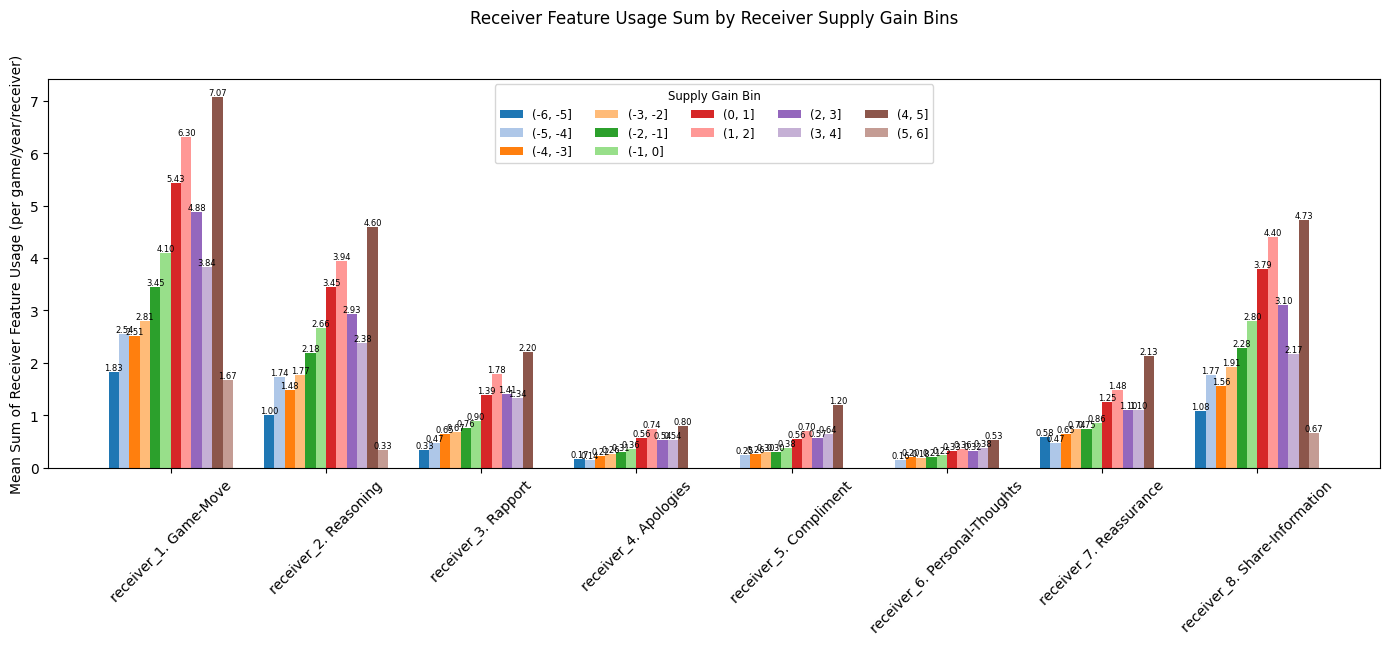

In [31]:
# 按照相同的 game_id, year, receiver 聚合 receiver features，再画图

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_feature_usage_by_receiver_group_and_supply_gain_bins(
    bins=[-10, -6, -4, -2, 0, 2, 4, 6, 8, 10],
    include_extreme_bins=True
):
    """
    先对相同的 game_id, year, receiver 的 receiver features 求和，再按 supply_gain_bin 画图。
    """
    df = df_sender_receiver.copy()
    features = [
        col for col in df.columns
        if col.startswith(('receiver_1.','receiver_2.','receiver_3.','receiver_4.','receiver_5.','receiver_6.','receiver_7.','receiver_8.'))
    ]

    # 先去除 receiver_supply_gain 为 nan 或 inf 的行，避免分箱出错
    df = df[np.isfinite(df['receiver_supply_gain'])]

    # 提取 year 信息
    def extract_year(phase_name):
        # 假设 phase_name 形如 'S1901M' 或 'F1902A'
        import re
        m = re.search(r'(\d{4})', str(phase_name))
        return int(m.group(1)) if m else np.nan

    df['year'] = df['phase_name'].apply(extract_year)

    # 按 game_id, year, receiver 聚合
    group_cols = ['game_id', 'year', 'receiver']
    agg_dict = {f: 'sum' for f in features}
    agg_dict['receiver_supply_gain'] = 'first'  # 每组的 supply_gain 取第一个（假设同组一致）
    df_grouped = df.groupby(group_cols, as_index=False).agg(agg_dict)

    # 分箱
    if include_extreme_bins:
        extended_bins = [-np.inf] + bins + [np.inf]
    else:
        extended_bins = bins.copy()
    bin_labels = []
    for i in range(len(extended_bins)-1):
        left = extended_bins[i]
        right = extended_bins[i+1]
        if left == -np.inf:
            label = f"(-inf, {right}]"
        elif right == np.inf:
            label = f"({left}, inf)"
        else:
            label = f"({left}, {right}]"
        bin_labels.append(label)

    df_grouped['supply_gain_bin'] = pd.cut(
        df_grouped['receiver_supply_gain'],
        bins=extended_bins,
        labels=bin_labels,
        right=True,
        include_lowest=True
    )

    print("supply_gain_bin value counts (grouped):")
    print(df_grouped['supply_gain_bin'].value_counts(dropna=False))

    # 融化
    df_melt = df_grouped.melt(
        id_vars=['supply_gain_bin'],
        value_vars=features,
        var_name='feature',
        value_name='count'
    )
    df_melt = df_melt[df_melt['supply_gain_bin'].notna()]

    # 分组求均值（每个bin下，每个feature的平均sum）
    group_means = (
        df_melt
        .groupby(['supply_gain_bin', 'feature'])['count']
        .mean()
        .unstack()
    )
    group_means = group_means[features]

    print("group_means index (bins with data):", group_means.index.tolist())

    # 画图
    all_bin_labels = bin_labels
    plt.figure(figsize=(14, 8))
    x = np.arange(len(features))
    n_bins = len(all_bin_labels)
    width = 0.8 / n_bins if n_bins > 0 else 0.8

    base_colors = plt.cm.tab10.colors if n_bins <= 10 else plt.cm.tab20.colors
    colors = base_colors * (n_bins // len(base_colors) + 1)

    for idx, bin_label in enumerate(all_bin_labels):
        if bin_label in group_means.index:
            yvals = np.array(group_means.loc[bin_label].values, dtype=float)
        else:
            yvals = np.zeros(len(features))
        mask = np.isfinite(yvals)
        plt.bar(
            x[mask] + idx*width,
            yvals[mask],
            width=width,
            label=str(bin_label),
            color=colors[idx % len(colors)]
        )

    plt.xticks(
        x + width*(n_bins-1)/2,
        features,
        rotation=45
    )
    plt.ylabel('Mean Sum of Receiver Feature Usage (per game/year/receiver)')
    plt.title('Receiver Feature Usage Sum by Receiver Supply Gain Bins', pad=40)
    plt.legend(
        title='Supply Gain Bin',
        loc='upper center',
        ncol=min(n_bins, 5),
        fontsize='small',
        title_fontsize='small'
    )
    plt.tight_layout(rect=[0, 0.08, 1, 0.90])

    # 在每根 bar 上标注数值
    for idx, bin_label in enumerate(all_bin_labels):
        if bin_label in group_means.index:
            yvals = np.array(group_means.loc[bin_label].values, dtype=float)
        else:
            yvals = np.zeros(len(features))
        for j, val in enumerate(yvals):
            if np.isfinite(val) and val != 0:
                plt.text(
                    x[j] + idx*width,
                    val,
                    f'{val:.2f}',
                    ha='center',
                    va='bottom',
                    fontsize=6,
                    rotation=0
                )

    plt.show()

# 调用示例
plot_feature_usage_by_receiver_group_and_supply_gain_bins(bins=[-6, -5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5, 6], include_extreme_bins=False)

In [32]:
filtered_df = df_sender_receiver[(df_sender_receiver['receiver_supply_gain'] > 1) & (df_sender_receiver['receiver_supply_gain'] <= 6)]


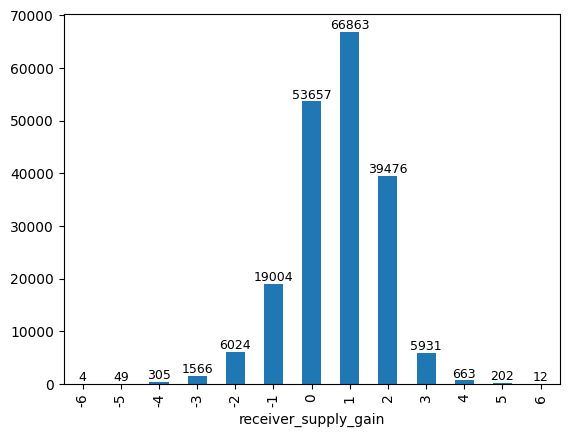

In [33]:
ax = df_sender_receiver.receiver_supply_gain.value_counts().sort_index().plot(kind='bar')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=9)

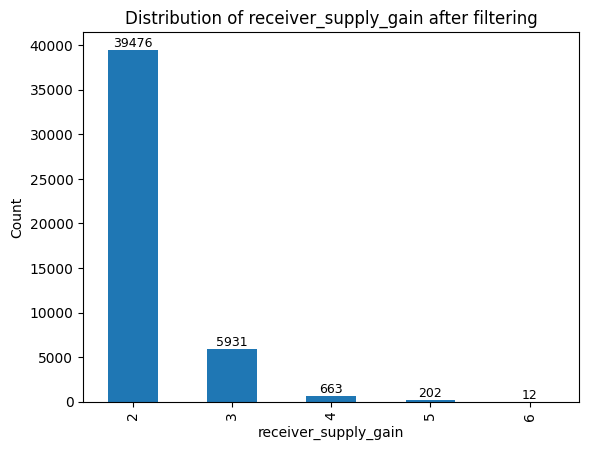

In [42]:
ax = filtered_df.receiver_supply_gain.value_counts().sort_index().plot(kind='bar')
plt.xlabel('receiver_supply_gain')
plt.ylabel('Count')
plt.title('Distribution of receiver_supply_gain after filtering')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2, p.get_height()), 
                ha='center', va='bottom', fontsize=9)
plt.show()

In [43]:
# You are play as {c1}, and you will negotiate with {c2} so that it will play moves that are beneficial to your board position, either this turn or in future turns.
filtered_df.head()

,game_id,phase_name,sender,receiver,sender_message,receiver_message,sender_time_sent,receiver_time_sent,sender_1. Game-Move,sender_2. Reasoning,sender_3. Rapport,sender_4. Apologies,sender_5. Compliment,sender_6. Personal-Thoughts,sender_7. Reassurance,sender_8. Share-Information,receiver_1. Game-Move,receiver_2. Reasoning,receiver_3. Rapport,receiver_4. Apologies,receiver_5. Compliment,receiver_6. Personal-Thoughts,receiver_7. Reassurance,receiver_8. Share-Information,receiver_supply_gain,sender_supply_gain,taskeval
1,77032,F1901M,RUSSIA,GERMANY,England has told me that he will support his a...,"I like the DMZ, but we'll have to see about Sw...",98391,4898,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,2,2,-0.061471
4,77032,S1901M,RUSSIA,FRANCE,What are your plans with England and Germany? ...,I have no plans at the moment; what did you ha...,175,264,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.049975
5,77032,S1901M,RUSSIA,FRANCE,"Probably Austia, but i will begin neutrally to...",I feel the same way. :)\r,526,722,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,2,0.049975
6,77032,F1901M,RUSSIA,TURKEY,I'll support con. to bulg if you want to try a...,"i would appreciate that, thank you.\r",78707,79037,1,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,2,2,-0.105522
7,77032,F1901M,RUSSIA,TURKEY,I got it! that said. I cannot support with a f...,oh dammit- forgot to look at what your unit wa...,129437,129635,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,2,2,-0.105522


In [38]:
import json

# 构建Alpaca格式的数据
alpaca_data = []
for idx, row in filtered_df.iterrows():
    sender_message = row['sender_message']
    receiver_message = row['receiver_message'] if 'receiver_message' in row else None
    if pd.isna(sender_message) or pd.isna(receiver_message):
        continue
    instruction = "You are playing diplomacy game, you will negotiate with the other player so that it will play moves that are beneficial to your board position, either this turn or in future turns."

    alpaca_data.append({
        "instruction": instruction,
        "input": sender_message,
        "output": receiver_message
    })

# 保存为json文件
with open("alpaca_format_data.json", "w", encoding="utf-8") as f:
    json.dump(alpaca_data, f, ensure_ascii=False, indent=2)
